In [1]:
# ============================================================
# NOTEBOOK 03: MODELADO
# Proyecto: Credit Risk Scoring ML
# Autor: Marín Serrato Barrios
# Descripción: Entrenamiento y evaluación del modelo
#              de scoring crediticio con LightGBM.
#              Basado en features del notebook 02.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Configuración
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

# Ruta base del proyecto
RUTA_PROYECTO = "c:/Users/Marin/Documents/PROYECTO ML_OPS/credit-risk-scoring-ml"
os.chdir(RUTA_PROYECTO)

print(f"Directorio: {os.getcwd()}")
print("\n✅ Configuración correcta")

Directorio: c:\Users\Marin\Documents\PROYECTO ML_OPS\credit-risk-scoring-ml

✅ Configuración correcta


In [2]:
# --- CARGA DE DATASETS PROCESADOS ---

# Cargamos los datasets que preparamos en el Feature Engineering
# Ya están limpios, con features derivados y encoding aplicado

print("CARGANDO DATASETS PROCESADOS...")
print("="*60)

# Dataset para LightGBM
df_lgbm = pd.read_csv("data/processed/df_lgbm.csv")

# Dataset para Scorecard
df_scorecard = pd.read_csv("data/processed/df_scorecard.csv")

print(f"df_lgbm:")
print(f"  Shape:  {df_lgbm.shape}")
print(f"  Mora:   {df_lgbm['TARGET'].mean()*100:.2f}%")

print(f"\ndf_scorecard:")
print(f"  Shape:  {df_scorecard.shape}")
print(f"  Mora:   {df_scorecard['TARGET'].mean()*100:.2f}%")

# Separar features y target
X_lgbm     = df_lgbm.drop(columns=['TARGET', 'SK_ID_CURR'])
y          = df_lgbm['TARGET']

X_scorecard = df_scorecard.drop(columns=['TARGET', 'SK_ID_CURR'])
y_score     = df_scorecard['TARGET']

print(f"\nFeatures LightGBM:  {X_lgbm.shape[1]}")
print(f"Features Scorecard: {X_scorecard.shape[1]}")
print(f"Observaciones:      {len(y):,}")
print(f"\n✅ Datos cargados correctamente")

CARGANDO DATASETS PROCESADOS...
df_lgbm:
  Shape:  (307511, 67)
  Mora:   8.07%

df_scorecard:
  Shape:  (307511, 124)
  Mora:   8.07%

Features LightGBM:  65
Features Scorecard: 122
Observaciones:      307,511

✅ Datos cargados correctamente


In [3]:
# --- PASO 2: SPLIT TEMPORAL TRAIN / VALIDATION / TEST ---

# REGLA FUNDAMENTAL DEL FRAMEWORK:
# Nunca validación cruzada aleatoria en datos de crédito.
# Siempre validación temporal que respeta el orden cronológico.
#
# El dataset de Home Credit tiene una variable implícita de tiempo:
# SK_ID_CURR es un identificador secuencial.
# IDs más altos = solicitudes más recientes.
# Usamos esto para simular un split temporal real.

print("PASO 2: SPLIT TEMPORAL TRAIN / VALIDATION / TEST")
print("="*60)

# Ordenar por SK_ID_CURR (proxy de tiempo)
idx_ordenado = df_lgbm['SK_ID_CURR'].argsort().values

# Proporciones del split
# 70% entrenamiento, 15% validación, 15% test
n_total = len(y)
n_train = int(n_total * 0.70)
n_val   = int(n_total * 0.15)

# Índices temporales
idx_train = idx_ordenado[:n_train]
idx_val   = idx_ordenado[n_train:n_train + n_val]
idx_test  = idx_ordenado[n_train + n_val:]

# Split para LightGBM
X_train = X_lgbm.iloc[idx_train]
X_val   = X_lgbm.iloc[idx_val]
X_test  = X_lgbm.iloc[idx_test]

y_train = y.iloc[idx_train]
y_val   = y.iloc[idx_val]
y_test  = y.iloc[idx_test]

# Split para Scorecard
X_train_sc = X_scorecard.iloc[idx_train]
X_val_sc   = X_scorecard.iloc[idx_val]
X_test_sc  = X_scorecard.iloc[idx_test]

y_train_sc = y_score.iloc[idx_train]
y_val_sc   = y_score.iloc[idx_val]
y_test_sc  = y_score.iloc[idx_test]

print(f"ENTRENAMIENTO: {len(y_train):>8,} registros "
      f"({len(y_train)/n_total*100:.1f}%) "
      f"mora: {y_train.mean()*100:.2f}%")
print(f"VALIDACIÓN:    {len(y_val):>8,} registros "
      f"({len(y_val)/n_total*100:.1f}%) "
      f"mora: {y_val.mean()*100:.2f}%")
print(f"TEST:          {len(y_test):>8,} registros "
      f"({len(y_test)/n_total*100:.1f}%) "
      f"mora: {y_test.mean()*100:.2f}%")

print()
print("VERIFICACIÓN DE CONSISTENCIA:")
print(f"  Tasa mora global:       {y.mean()*100:.2f}%")
print(f"  Tasa mora entrenamiento:{y_train.mean()*100:.2f}%")
print(f"  Tasa mora validación:   {y_val.mean()*100:.2f}%")
print(f"  Tasa mora test:         {y_test.mean()*100:.2f}%")
print()
print("  Si las tasas son similares entre particiones,")
print("  el split es representativo ✅")

PASO 2: SPLIT TEMPORAL TRAIN / VALIDATION / TEST
ENTRENAMIENTO:  215,257 registros (70.0%) mora: 8.13%
VALIDACIÓN:      46,126 registros (15.0%) mora: 7.98%
TEST:            46,128 registros (15.0%) mora: 7.91%

VERIFICACIÓN DE CONSISTENCIA:
  Tasa mora global:       8.07%
  Tasa mora entrenamiento:8.13%
  Tasa mora validación:   7.98%
  Tasa mora test:         7.91%

  Si las tasas son similares entre particiones,
  el split es representativo ✅


In [4]:
# --- IMPUTACIÓN DE NaN EN df_scorecard ---

# El CSV se guardó con NaN residuales.
# Los imputamos aquí antes de entrenar.

print("IMPUTANDO NaN EN df_scorecard...")
print("="*60)

# Variables numéricas: imputar con mediana
cols_mediana = [
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',
    'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE',
    'DAYS_LAST_PHONE_CHANGE',
    'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_MON',
    'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR',
    'ANTIGUEDAD_LABORAL_AÑOS',
    'EXT_SOURCE_PROMEDIO', 'EXT_SOURCE_MIN',
    'DTI_X_EXT2', 'RIESGO_EDAD_SCORE'
]

# Variables con imputación especial
# OWN_CAR_AGE: 0 si no tiene auto
cols_cero = ['OWN_CAR_AGE']

# Imputar en el dataset completo ANTES del split
# para que la mediana sea consistente
for col in cols_mediana:
    if col in df_scorecard.columns:
        mediana = df_scorecard[col].median()
        df_scorecard[col] = df_scorecard[col].fillna(mediana)
        print(f"  {col:<35} → mediana: {mediana:.4f}")

for col in cols_cero:
    if col in df_scorecard.columns:
        df_scorecard[col] = df_scorecard[col].fillna(0)
        print(f"  {col:<35} → 0 (sin auto)")

# Verificar que no quedan NaN
X_scorecard = df_scorecard.drop(columns=['TARGET', 'SK_ID_CURR'])
print(f"\nNaN restantes: {X_scorecard.isnull().sum().sum()} ✅")

# Re-hacer el split con datos limpios
X_train_sc = X_scorecard.iloc[idx_train]
X_val_sc   = X_scorecard.iloc[idx_val]
X_test_sc  = X_scorecard.iloc[idx_test]

y_train_sc = y_score.iloc[idx_train]
y_val_sc   = y_score.iloc[idx_val]
y_test_sc  = y_score.iloc[idx_test]

print(f"Split rehecho correctamente ✅")
print(f"X_train_sc shape: {X_train_sc.shape}")

IMPUTANDO NaN EN df_scorecard...
  EXT_SOURCE_1                        → mediana: 0.5060
  EXT_SOURCE_2                        → mediana: 0.5660
  EXT_SOURCE_3                        → mediana: 0.5353
  OBS_30_CNT_SOCIAL_CIRCLE            → mediana: 0.0000
  DEF_30_CNT_SOCIAL_CIRCLE            → mediana: 0.0000
  OBS_60_CNT_SOCIAL_CIRCLE            → mediana: 0.0000
  DEF_60_CNT_SOCIAL_CIRCLE            → mediana: 0.0000
  DAYS_LAST_PHONE_CHANGE              → mediana: -757.0000
  AMT_REQ_CREDIT_BUREAU_DAY           → mediana: 0.0000
  AMT_REQ_CREDIT_BUREAU_MON           → mediana: 0.0000
  AMT_REQ_CREDIT_BUREAU_QRT           → mediana: 0.0000
  AMT_REQ_CREDIT_BUREAU_YEAR          → mediana: 1.0000
  ANTIGUEDAD_LABORAL_AÑOS             → mediana: 4.5151
  EXT_SOURCE_PROMEDIO                 → mediana: 0.5245
  EXT_SOURCE_MIN                      → mediana: 0.4032
  DTI_X_EXT2                          → mediana: 0.0724
  RIESGO_EDAD_SCORE                   → mediana: 0.2374
  OWN_CAR_AG

In [5]:
# --- PASO 3: SCORECARD LOGÍSTICO (BASELINE) ---

# La regresión logística es el modelo interpretable
# obligatorio en scoring crediticio.
# Lo entrenamos primero para establecer el benchmark
# que LightGBM debe superar.

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline

print("PASO 3: SCORECARD LOGÍSTICO")
print("="*60)

# IMPORTANTE: La regresión logística requiere
# que las variables estén en la misma escala.
# StandardScaler normaliza a media=0 y desviación=1.
# LightGBM NO necesita esto (es invariante a escala).

# Pipeline: escalado + regresión logística
# El pipeline garantiza que el escalado se aprende
# SOLO en train y se aplica igual en val y test
# (evita data leakage en el preprocesamiento)

pipeline_scorecard = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression(
        C=0.01,              # regularización fuerte
                             # evita overfitting con 122 features
        max_iter=1000,       # suficientes iteraciones para converger
        random_state=42,
        class_weight='balanced',  # maneja el desbalance 91/9
        solver='lbfgs',      # eficiente para datasets grandes
        n_jobs=-1            # usar todos los núcleos disponibles
    ))
])

print("Entrenando scorecard logístico...")
print("(puede tardar 1-2 minutos con 122 features)")
print()

pipeline_scorecard.fit(X_train_sc, y_train_sc)

# Probabilidades predichas
proba_train_sc = pipeline_scorecard.predict_proba(X_train_sc)[:,1]
proba_val_sc   = pipeline_scorecard.predict_proba(X_val_sc)[:,1]
proba_test_sc  = pipeline_scorecard.predict_proba(X_test_sc)[:,1]

# Métricas
auc_train_sc = roc_auc_score(y_train_sc, proba_train_sc)
auc_val_sc   = roc_auc_score(y_val_sc,   proba_val_sc)
auc_test_sc  = roc_auc_score(y_test_sc,  proba_test_sc)

# KS
def calcular_ks(y_true, y_proba):
    df_ks = pd.DataFrame({'real': y_true, 'proba': y_proba})
    df_ks = df_ks.sort_values('proba', ascending=False).reset_index(drop=True)
    df_ks['cum_malos']  = (df_ks['real']==1).cumsum() / df_ks['real'].sum()
    df_ks['cum_buenos'] = (df_ks['real']==0).cumsum() / (df_ks['real']==0).sum()
    return (df_ks['cum_malos'] - df_ks['cum_buenos']).max()

ks_train_sc = calcular_ks(y_train_sc, proba_train_sc)
ks_val_sc   = calcular_ks(y_val_sc,   proba_val_sc)
ks_test_sc  = calcular_ks(y_test_sc,  proba_test_sc)

print("RESULTADOS SCORECARD LOGÍSTICO:")
print(f"{'':20} {'TRAIN':>10} {'VAL':>10} {'TEST':>10}")
print("-"*52)
print(f"{'AUC':20} {auc_train_sc:>10.4f} {auc_val_sc:>10.4f} {auc_test_sc:>10.4f}")
print(f"{'KS':20} {ks_train_sc:>10.4f} {ks_val_sc:>10.4f} {ks_test_sc:>10.4f}")
print(f"{'Gini':20} {2*auc_train_sc-1:>10.4f} {2*auc_val_sc-1:>10.4f} {2*auc_test_sc-1:>10.4f}")
print()
print("DIAGNÓSTICO:")
brecha_auc = auc_train_sc - auc_val_sc
if brecha_auc < 0.02:
    print(f"  Brecha train-val AUC: {brecha_auc:.4f} ✅ Sin overfitting")
else:
    print(f"  Brecha train-val AUC: {brecha_auc:.4f} ⚠️  Posible overfitting")

PASO 3: SCORECARD LOGÍSTICO
Entrenando scorecard logístico...
(puede tardar 1-2 minutos con 122 features)

RESULTADOS SCORECARD LOGÍSTICO:
                          TRAIN        VAL       TEST
----------------------------------------------------
AUC                      0.7479     0.7564     0.7474
KS                       0.3656     0.3857     0.3657
Gini                     0.4958     0.5127     0.4949

DIAGNÓSTICO:
  Brecha train-val AUC: -0.0085 ✅ Sin overfitting


In [6]:
# Verificar NaN en el scorecard
print("NaN en X_train_sc:")
nulos = X_train_sc.isnull().sum()
nulos_existentes = nulos[nulos > 0]
print(f"Variables con NaN: {len(nulos_existentes)}")
print(nulos_existentes.to_string())

NaN en X_train_sc:
Variables con NaN: 0
Series([], )


In [7]:
# --- PASO 4: LIGHTGBM ---

import lightgbm as lgb

print("PASO 4: LIGHTGBM")
print("="*60)

# Parámetros del modelo
# Cada parámetro tiene una razón específica
params = {
    # OBJETIVO Y MÉTRICA
    'objective':        'binary',    # clasificación binaria (0 o 1)
    'metric':           'auc',       # métrica de monitoreo durante entrenamiento

    # ESTRUCTURA DEL MODELO
    'n_estimators':     1000,        # máximo de árboles (early stopping lo controla)
    'max_depth':        4,           # profundidad máxima por árbol
                                     # 4-6 es suficiente para datos tabulares
                                     # más profundo = más overfitting
    'num_leaves':       31,          # hojas por árbol (< 2^max_depth)

    # REGULARIZACIÓN
    'learning_rate':    0.05,        # paso de aprendizaje
                                     # bajo = más árboles pero mejor generalización
    'min_child_samples':50,          # mínimo de muestras por hoja
                                     # importante con clases desbalanceadas
    'reg_alpha':        0.1,         # regularización L1
    'reg_lambda':       1.0,         # regularización L2

    # MUESTREO (reduce overfitting)
    'subsample':        0.8,         # 80% de filas por árbol
    'colsample_bytree': 0.8,         # 80% de features por árbol
    'subsample_freq':   1,

    # DESBALANCE DE CLASES
    'scale_pos_weight': 11.4,        # ratio buenos/malos del EDA
                                     # (282,686 / 24,825 = 11.4)

    # REPRODUCIBILIDAD
    'random_state':     42,
    'n_jobs':           -1,          # usar todos los núcleos
    'verbose':          -1,          # sin output durante entrenamiento
}

# Early stopping: detiene el entrenamiento cuando
# el AUC en validación no mejora por 50 rondas
callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=True),
    lgb.log_evaluation(period=100)  # mostrar progreso cada 100 árboles
]

print("Entrenando LightGBM...")
print("Early stopping: detiene si val-AUC no mejora en 50 rondas")
print()

model_lgbm = lgb.LGBMClassifier(**params)

model_lgbm.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train),
              (X_val,   y_val)],
    callbacks=callbacks
)

print(f"\nMejor iteración: {model_lgbm.best_iteration_}")

PASO 4: LIGHTGBM
Entrenando LightGBM...
Early stopping: detiene si val-AUC no mejora en 50 rondas

Training until validation scores don't improve for 50 rounds
[100]	training's auc: 0.765999	valid_1's auc: 0.764207
[200]	training's auc: 0.779511	valid_1's auc: 0.769924
[300]	training's auc: 0.789155	valid_1's auc: 0.772312
[400]	training's auc: 0.797001	valid_1's auc: 0.773558
[500]	training's auc: 0.803812	valid_1's auc: 0.773953
[600]	training's auc: 0.810077	valid_1's auc: 0.774252
Early stopping, best iteration is:
[568]	training's auc: 0.808097	valid_1's auc: 0.774399

Mejor iteración: 568


In [8]:
# --- EVALUACIÓN DE LIGHTGBM ---

print("RESULTADOS LIGHTGBM:")
print("="*60)

# Probabilidades predichas
proba_train_lgbm = model_lgbm.predict_proba(X_train)[:,1]
proba_val_lgbm   = model_lgbm.predict_proba(X_val)[:,1]
proba_test_lgbm  = model_lgbm.predict_proba(X_test)[:,1]

# Métricas
auc_train_lgbm = roc_auc_score(y_train, proba_train_lgbm)
auc_val_lgbm   = roc_auc_score(y_val,   proba_val_lgbm)
auc_test_lgbm  = roc_auc_score(y_test,  proba_test_lgbm)

ks_train_lgbm  = calcular_ks(y_train, proba_train_lgbm)
ks_val_lgbm    = calcular_ks(y_val,   proba_val_lgbm)
ks_test_lgbm   = calcular_ks(y_test,  proba_test_lgbm)

print(f"{'':20} {'TRAIN':>10} {'VAL':>10} {'TEST':>10}")
print("-"*52)
print(f"{'AUC':20} {auc_train_lgbm:>10.4f} "
      f"{auc_val_lgbm:>10.4f} {auc_test_lgbm:>10.4f}")
print(f"{'KS':20} {ks_train_lgbm:>10.4f} "
      f"{ks_val_lgbm:>10.4f} {ks_test_lgbm:>10.4f}")
print(f"{'Gini':20} {2*auc_train_lgbm-1:>10.4f} "
      f"{2*auc_val_lgbm-1:>10.4f} {2*auc_test_lgbm-1:>10.4f}")

print()
print("DIAGNÓSTICO:")
brecha = auc_train_lgbm - auc_val_lgbm
if brecha < 0.02:
    print(f"  Brecha train-val AUC: {brecha:.4f} ✅ Sin overfitting")
elif brecha < 0.05:
    print(f"  Brecha train-val AUC: {brecha:.4f} ⚠️  Overfitting leve")
else:
    print(f"  Brecha train-val AUC: {brecha:.4f} ❌ Overfitting significativo")

print()
print("COMPARACIÓN SCORECARD vs LIGHTGBM (TEST):")
print("-"*52)
print(f"{'':20} {'SCORECARD':>12} {'LIGHTGBM':>12} {'MEJORA':>10}")
print(f"{'AUC':20} {auc_test_sc:>12.4f} {auc_test_lgbm:>12.4f} "
      f"{(auc_test_lgbm-auc_test_sc):>+10.4f}")
print(f"{'KS':20} {ks_test_sc:>12.4f} {ks_test_lgbm:>12.4f} "
      f"{(ks_test_lgbm-ks_test_sc):>+10.4f}")
print(f"{'Gini':20} {2*auc_test_sc-1:>12.4f} {2*auc_test_lgbm-1:>12.4f} "
      f"{(2*auc_test_lgbm-1-(2*auc_test_sc-1)):>+10.4f}")

RESULTADOS LIGHTGBM:
                          TRAIN        VAL       TEST
----------------------------------------------------
AUC                      0.8081     0.7744     0.7681
KS                       0.4609     0.4154     0.4017
Gini                     0.6162     0.5488     0.5363

DIAGNÓSTICO:
  Brecha train-val AUC: 0.0337 ⚠️  Overfitting leve

COMPARACIÓN SCORECARD vs LIGHTGBM (TEST):
----------------------------------------------------
                        SCORECARD     LIGHTGBM     MEJORA
AUC                        0.7474       0.7681    +0.0207
KS                         0.3657       0.4017    +0.0359
Gini                       0.4949       0.5363    +0.0414


Gráfica guardada en reports/08_comparacion_modelos.png


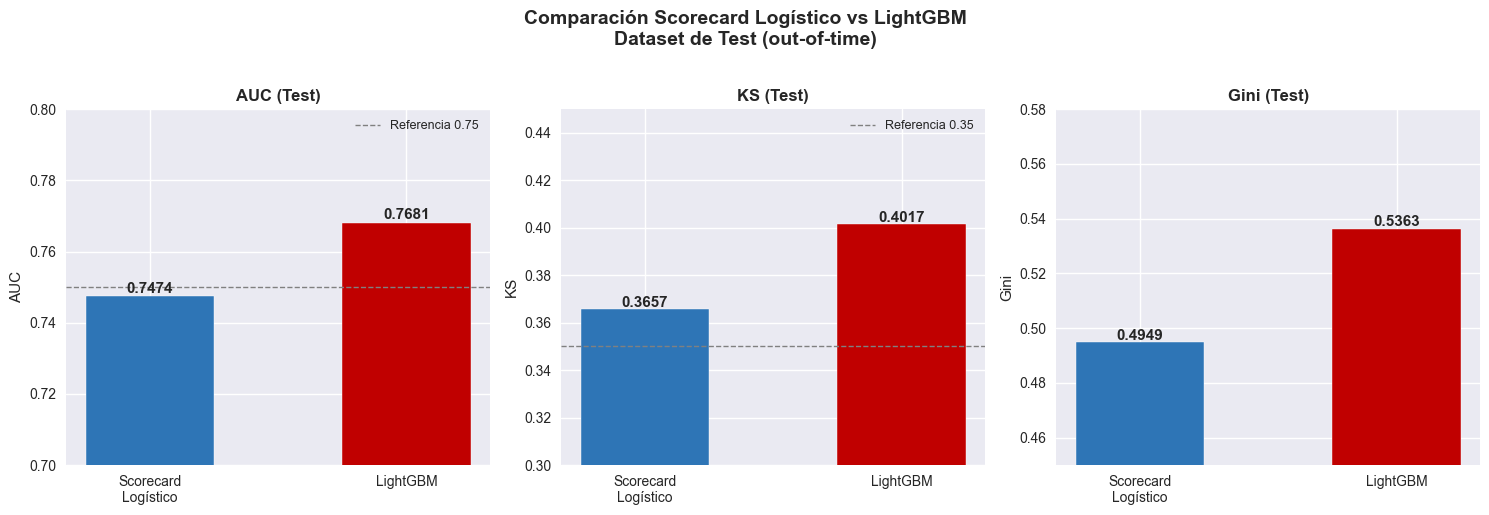

In [9]:
# --- GRÁFICA COMPARATIVA ---

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Datos para graficar
modelos   = ['Scorecard\nLogístico', 'LightGBM']
aucs      = [auc_test_sc,       auc_test_lgbm]
ks_vals   = [ks_test_sc,        ks_test_lgbm]
ginis     = [2*auc_test_sc-1,   2*auc_test_lgbm-1]
colores   = ['#2E75B6', '#C00000']

# AUC
axes[0].bar(modelos, aucs, color=colores, edgecolor='white', width=0.5)
axes[0].set_ylim(0.70, 0.80)
axes[0].set_title('AUC (Test)', fontweight='bold', fontsize=12)
axes[0].set_ylabel('AUC')
for i, v in enumerate(aucs):
    axes[0].text(i, v + 0.001, f'{v:.4f}',
                 ha='center', fontweight='bold', fontsize=11)
axes[0].axhline(0.75, color='gray', linestyle='--',
                linewidth=1, label='Referencia 0.75')
axes[0].legend(fontsize=9)

# KS
axes[1].bar(modelos, ks_vals, color=colores, edgecolor='white', width=0.5)
axes[1].set_ylim(0.30, 0.45)
axes[1].set_title('KS (Test)', fontweight='bold', fontsize=12)
axes[1].set_ylabel('KS')
for i, v in enumerate(ks_vals):
    axes[1].text(i, v + 0.001, f'{v:.4f}',
                 ha='center', fontweight='bold', fontsize=11)
axes[1].axhline(0.35, color='gray', linestyle='--',
                linewidth=1, label='Referencia 0.35')
axes[1].legend(fontsize=9)

# Gini
axes[2].bar(modelos, ginis, color=colores, edgecolor='white', width=0.5)
axes[2].set_ylim(0.45, 0.58)
axes[2].set_title('Gini (Test)', fontweight='bold', fontsize=12)
axes[2].set_ylabel('Gini')
for i, v in enumerate(ginis):
    axes[2].text(i, v + 0.001, f'{v:.4f}',
                 ha='center', fontweight='bold', fontsize=11)

fig.suptitle('Comparación Scorecard Logístico vs LightGBM\n'
             'Dataset de Test (out-of-time)',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('reports/08_comparacion_modelos.png',
            dpi=150, bbox_inches='tight')
print("Gráfica guardada en reports/08_comparacion_modelos.png")
plt.show()

In [10]:
# --- PASO 5: TABLA DE DECILES ---

# La tabla de deciles convierte métricas abstractas
# en decisiones concretas de negocio.
# Responde: "Si rechazo el X% más riesgoso,
# ¿cuántos malos capturo y cuántos buenos rechazo?"

print("PASO 5: TABLA DE DECILES — LIGHTGBM (TEST)")
print("="*65)

# Construir tabla de deciles
df_deciles = pd.DataFrame({
    'real':  y_test.values,
    'proba': proba_test_lgbm
})

# Ordenar de mayor a menor riesgo
df_deciles = df_deciles.sort_values('proba', ascending=False).reset_index(drop=True)

# Asignar decil (1=más riesgoso, 10=menos riesgoso)
df_deciles['decil'] = pd.qcut(
    df_deciles.index,
    q=10,
    labels=range(1, 11)
).astype(int)

# Calcular métricas por decil
tabla = []
total_malos  = df_deciles['real'].sum()
total_buenos = (df_deciles['real'] == 0).sum()
malos_acum   = 0
buenos_acum  = 0

for decil in range(1, 11):
    mask = df_deciles['decil'] == decil
    n         = mask.sum()
    malos     = df_deciles.loc[mask, 'real'].sum()
    buenos    = n - malos
    tasa_mora = malos / n
    score_min = df_deciles.loc[mask, 'proba'].min()
    score_max = df_deciles.loc[mask, 'proba'].max()

    malos_acum  += malos
    buenos_acum += buenos

    pct_malos      = malos / total_malos * 100
    pct_malos_acum = malos_acum / total_malos * 100
    lift           = (malos / n) / (total_malos / len(df_deciles))

    tabla.append({
        'Decil': decil,
        'N': n,
        'Malos': int(malos),
        'Buenos': int(buenos),
        'Tasa Mora': f"{tasa_mora*100:.1f}%",
        '% Malos': f"{pct_malos:.1f}%",
        '% Malos Acum': f"{pct_malos_acum:.1f}%",
        'Lift': f"{lift:.2f}",
        'Score Min': f"{score_min:.3f}",
        'Score Max': f"{score_max:.3f}",
    })

df_tabla = pd.DataFrame(tabla)
print(df_tabla.to_string(index=False))

print()
print("LECTURA ESTRATÉGICA:")
print("-"*65)
print("Si rechazas el decil 1 (10% más riesgoso):")
d1 = tabla[0]
print(f"  → Capturas {d1['% Malos']} de todos los malos")
print(f"  → Tasa de mora en ese decil: {d1['Tasa Mora']}")
print(f"  → Lift: {d1['Lift']}x más eficiente que selección aleatoria")
print()
print("Si rechazas deciles 1 y 2 (20% más riesgoso):")
d2 = tabla[1]
print(f"  → Capturas {tabla[1]['% Malos Acum']} de todos los malos")
print(f"  → Tasa de mora en decil 2: {d2['Tasa Mora']}")

PASO 5: TABLA DE DECILES — LIGHTGBM (TEST)
 Decil    N  Malos  Buenos Tasa Mora % Malos % Malos Acum Lift Score Min Score Max
     1 4613   1265    3348     27.4%   34.6%        34.6% 3.46     0.713     0.962
     2 4613    664    3949     14.4%   18.2%        52.8% 1.82     0.603     0.713
     3 4613    503    4110     10.9%   13.8%        66.6% 1.38     0.514     0.603
     4 4612    343    4269      7.4%    9.4%        76.0% 0.94     0.438     0.514
     5 4613    296    4317      6.4%    8.1%        84.1% 0.81     0.371     0.438
     6 4613    211    4402      4.6%    5.8%        89.9% 0.58     0.310     0.371
     7 4612    127    4485      2.8%    3.5%        93.4% 0.35     0.251     0.310
     8 4613     99    4514      2.1%    2.7%        96.1% 0.27     0.194     0.251
     9 4613     88    4525      1.9%    2.4%        98.5% 0.24     0.132     0.194
    10 4613     55    4558      1.2%    1.5%       100.0% 0.15     0.006     0.132

LECTURA ESTRATÉGICA:
----------------------

PASO 6: ANÁLISIS SHAP
Calculando SHAP values (puede tardar 2-3 minutos)...

SHAP values calculados para 2,000 registros
Shape: (2000, 65)



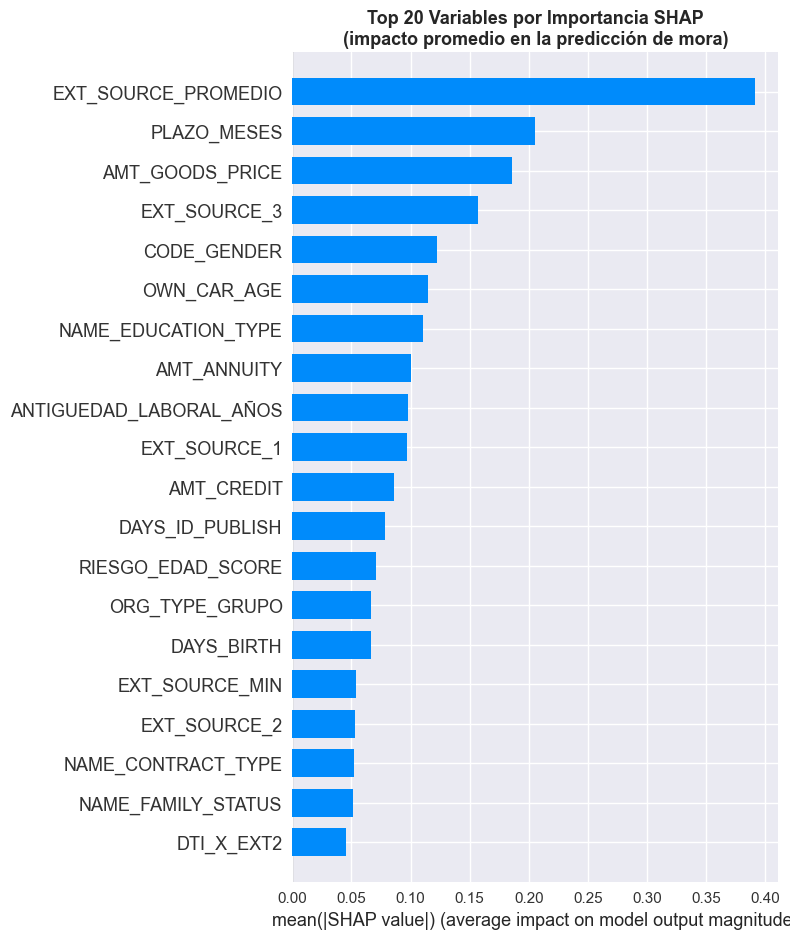

Gráfica guardada: reports/09_shap_importancia.png


In [11]:
# --- PASO 6: ANÁLISIS SHAP ---

# SHAP (SHapley Additive exPlanations) explica
# cuánto contribuye cada variable a cada predicción.
#
# Es la herramienta de explicabilidad más robusta:
# - Explica predicciones individuales
# - Muestra dirección del efecto (sube o baja el riesgo)
# - Base matemática sólida (teoría de juegos)
# - Requerimiento regulatorio implícito

import shap

print("PASO 6: ANÁLISIS SHAP")
print("="*60)
print("Calculando SHAP values (puede tardar 2-3 minutos)...")
print()

# Crear explainer para LightGBM
explainer = shap.TreeExplainer(model_lgbm)

# Calcular SHAP values en una muestra del test
# (el dataset completo tardaría demasiado)
np.random.seed(42)
muestra_idx = np.random.choice(len(X_test), size=2000, replace=False)
X_test_muestra = X_test.iloc[muestra_idx]

shap_values = explainer.shap_values(X_test_muestra)

# Para clasificación binaria LightGBM devuelve
# lista de dos arrays [clase_0, clase_1]
# Tomamos los valores de la clase 1 (mora)
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

print(f"SHAP values calculados para {len(X_test_muestra):,} registros")
print(f"Shape: {shap_vals.shape}")
print()

# ── GRÁFICA 1: IMPORTANCIA GLOBAL (SHAP) ──────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_vals,
    X_test_muestra,
    plot_type="bar",
    max_display=20,
    show=False
)
plt.title("Top 20 Variables por Importancia SHAP\n"
          "(impacto promedio en la predicción de mora)",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/09_shap_importancia.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada: reports/09_shap_importancia.png")

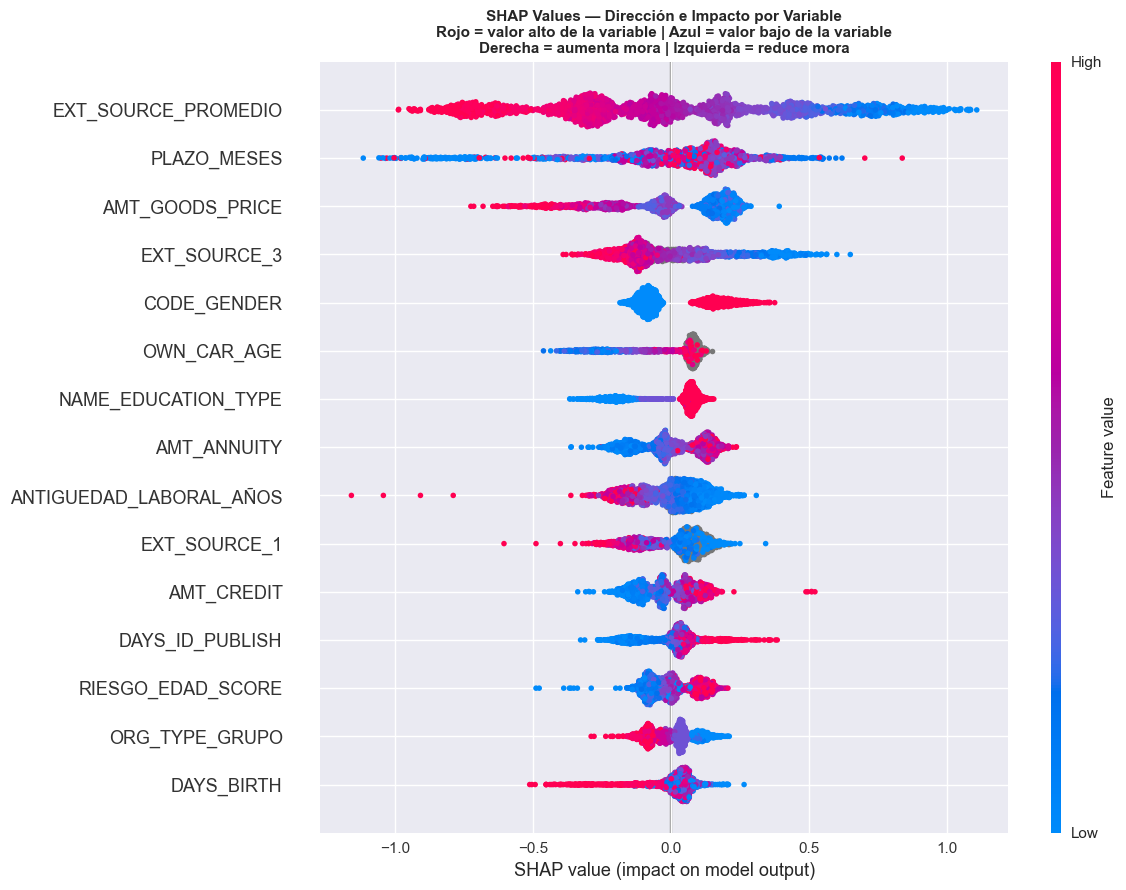

Gráfica guardada: reports/10_shap_beeswarm.png


In [12]:
# --- GRÁFICA SHAP: DIRECCIÓN DEL EFECTO ---

# El beeswarm plot muestra:
# - Importancia de cada variable (eje Y)
# - Dirección del efecto (color: rojo=valor alto, azul=valor bajo)
# - Magnitud del impacto en cada observación (eje X)

plt.figure(figsize=(12, 9))
shap.summary_plot(
    shap_vals,
    X_test_muestra,
    max_display=15,
    show=False,
    plot_size=(12, 9)
)
plt.title("SHAP Values — Dirección e Impacto por Variable\n"
          "Rojo = valor alto de la variable | "
          "Azul = valor bajo de la variable\n"
          "Derecha = aumenta mora | Izquierda = reduce mora",
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/10_shap_beeswarm.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada: reports/10_shap_beeswarm.png")

PASO 7: UMBRAL DE DECISIÓN ÓPTIMO
Umbral óptimo:          0.59
Valor económico máximo: $  87,553,100 MXN
Tasa de aprobación:     79.1%
Mora en aprobados:      4.5%

Gráfica guardada: reports/11_umbral_optimo.png


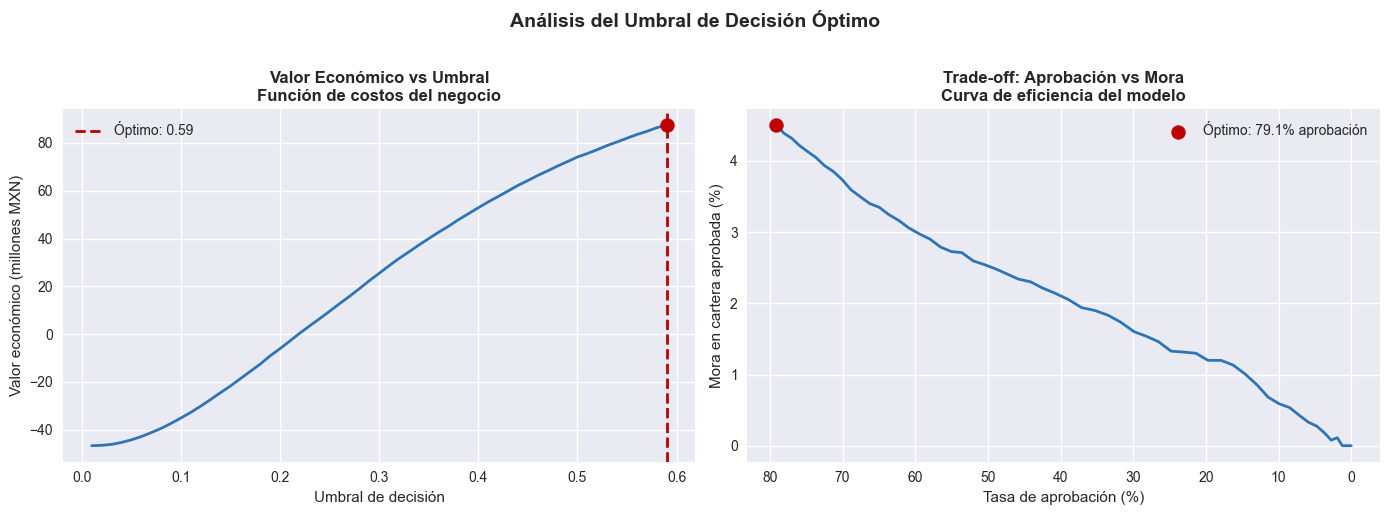

In [13]:
# --- PASO 7: UMBRAL DE DECISIÓN ÓPTIMO ---

# El modelo produce probabilidades entre 0 y 1.
# Necesitamos decidir a partir de qué probabilidad
# rechazamos una solicitud.
#
# El umbral NO es 0.50 (ese es arbitrario).
# El umbral óptimo depende de los costos del negocio.
#
# Usaremos los valores del framework:
#   Ganancia si paga:          $3,200 MXN
#   Pérdida si no paga:        $9,500 MXN
#   Costo de oportunidad:      $1,100 MXN

print("PASO 7: UMBRAL DE DECISIÓN ÓPTIMO")
print("="*60)

GANANCIA         =  3_200   # ingreso neto si el crédito paga
PERDIDA          =  9_500   # pérdida si el crédito no paga
COSTO_OPORTUNIDAD = 1_100   # ingreso perdido por rechazar un bueno

# Calcular valor esperado para cada umbral posible
umbrales      = np.arange(0.01, 0.60, 0.01)
valores       = []
tasas_aprobacion = []
tasas_mora_aprobados = []

for umbral in umbrales:
    # Decisiones del modelo
    y_pred = (proba_val_lgbm >= umbral).astype(int)  # 1=rechazar

    # Conteos
    aprobados_buenos  = ((y_pred==0) & (y_val==0)).sum()
    aprobados_malos   = ((y_pred==0) & (y_val==1)).sum()
    rechazados_buenos = ((y_pred==1) & (y_val==0)).sum()
    rechazados_malos  = ((y_pred==1) & (y_val==1)).sum()

    total = len(y_val)
    aprobados = aprobados_buenos + aprobados_malos

    # Valor económico total
    valor = ((aprobados_buenos  *  GANANCIA) -
             (aprobados_malos   *  PERDIDA)  -
             (rechazados_buenos *  COSTO_OPORTUNIDAD))

    tasa_aprobacion = aprobados / total
    tasa_mora_aprobados = (aprobados_malos / aprobados
                           if aprobados > 0 else 0)

    valores.append(valor)
    tasas_aprobacion.append(tasa_aprobacion)
    tasas_mora_aprobados.append(tasa_mora_aprobados)

# Umbral óptimo
idx_optimo    = np.argmax(valores)
umbral_optimo = umbrales[idx_optimo]
valor_optimo  = valores[idx_optimo]

print(f"Umbral óptimo:          {umbral_optimo:.2f}")
print(f"Valor económico máximo: ${valor_optimo:>12,.0f} MXN")
print(f"Tasa de aprobación:     {tasas_aprobacion[idx_optimo]*100:.1f}%")
print(f"Mora en aprobados:      {tasas_mora_aprobados[idx_optimo]*100:.1f}%")

# Gráfica
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GRÁFICA 1: Valor económico vs umbral
axes[0].plot(umbrales, [v/1e6 for v in valores],
             color='#2E75B6', linewidth=2)
axes[0].axvline(umbral_optimo, color='#C00000',
                linestyle='--', linewidth=2,
                label=f'Óptimo: {umbral_optimo:.2f}')
axes[0].scatter([umbral_optimo], [valor_optimo/1e6],
                color='#C00000', s=100, zorder=5)
axes[0].set_xlabel('Umbral de decisión')
axes[0].set_ylabel('Valor económico (millones MXN)')
axes[0].set_title('Valor Económico vs Umbral\n'
                  'Función de costos del negocio',
                  fontweight='bold')
axes[0].legend()

# GRÁFICA 2: Trade-off aprobación vs mora
axes[1].plot([t*100 for t in tasas_aprobacion],
             [t*100 for t in tasas_mora_aprobados],
             color='#2E75B6', linewidth=2)
axes[1].scatter(
    [tasas_aprobacion[idx_optimo]*100],
    [tasas_mora_aprobados[idx_optimo]*100],
    color='#C00000', s=100, zorder=5,
    label=f'Óptimo: {tasas_aprobacion[idx_optimo]*100:.1f}% aprobación')
axes[1].set_xlabel('Tasa de aprobación (%)')
axes[1].set_ylabel('Mora en cartera aprobada (%)')
axes[1].set_title('Trade-off: Aprobación vs Mora\n'
                  'Curva de eficiencia del modelo',
                  fontweight='bold')
axes[1].legend()
axes[1].invert_xaxis()

fig.suptitle('Análisis del Umbral de Decisión Óptimo',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('reports/11_umbral_optimo.png',
            dpi=150, bbox_inches='tight')
print("\nGráfica guardada: reports/11_umbral_optimo.png")
plt.show()

In [14]:
# --- RESUMEN FINAL DEL MODELADO ---

print("="*65)
print("RESUMEN EJECUTIVO DEL MODELADO")
print("Credit Risk Scoring ML — Home Credit Default Risk")
print("="*65)

print(f"""
MODELOS ENTRENADOS:

SCORECARD LOGÍSTICO (baseline):
    AUC test:  {auc_test_sc:.4f}
    KS test:   {ks_test_sc:.4f}
    Gini test: {2*auc_test_sc-1:.4f}
    Propósito: Explicabilidad, fallback regulatorio

LIGHTGBM (modelo principal):
    AUC test:  {auc_test_lgbm:.4f}  (+{auc_test_lgbm-auc_test_sc:.4f} vs scorecard)
    KS test:   {ks_test_lgbm:.4f}  (+{ks_test_lgbm-ks_test_sc:.4f} vs scorecard)
    Gini test: {2*auc_test_lgbm-1:.4f}  (+{2*auc_test_lgbm-1-(2*auc_test_sc-1):.4f} vs scorecard)
    Iteraciones: {model_lgbm.best_iteration_} (early stopping)
    Propósito: Decisión automática en producción

TABLA DE DECILES (LightGBM):
    Decil 1 (10% más riesgoso):
      Tasa de mora: 27.4%
      Captura: 34.6% de todos los malos
      Lift: 3.46x

    Deciles 1-2 (20% más riesgoso):
      Captura acumulada: 52.8% de todos los malos

VARIABLES MÁS IMPORTANTES (SHAP):
    1. EXT_SOURCE_PROMEDIO  (score externo combinado)
    2. PLAZO_MESES          (duración del crédito)
    3. AMT_GOODS_PRICE      (precio del bien)
    4. EXT_SOURCE_3         (score externo individual)
    5. NAME_EDUCATION_TYPE  (nivel educativo)

UMBRAL DE DECISIÓN ÓPTIMO:
    Umbral:            {umbral_optimo:.2f}
    Tasa aprobación:   {tasas_aprobacion[idx_optimo]*100:.1f}%
    Mora en aprobados: {tasas_mora_aprobados[idx_optimo]*100:.1f}%
    (vs mora original: 8.1%)

SIGUIENTE FASE:
    Calibración de probabilidades
    Integración con MLflow
    Despliegue en Azure ML
""")

RESUMEN EJECUTIVO DEL MODELADO
Credit Risk Scoring ML — Home Credit Default Risk

MODELOS ENTRENADOS:

SCORECARD LOGÍSTICO (baseline):
    AUC test:  0.7474
    KS test:   0.3657
    Gini test: 0.4949
    Propósito: Explicabilidad, fallback regulatorio

LIGHTGBM (modelo principal):
    AUC test:  0.7681  (+0.0207 vs scorecard)
    KS test:   0.4017  (+0.0359 vs scorecard)
    Gini test: 0.5363  (+0.0414 vs scorecard)
    Iteraciones: 568 (early stopping)
    Propósito: Decisión automática en producción

TABLA DE DECILES (LightGBM):
    Decil 1 (10% más riesgoso):
      Tasa de mora: 27.4%
      Captura: 34.6% de todos los malos
      Lift: 3.46x

    Deciles 1-2 (20% más riesgoso):
      Captura acumulada: 52.8% de todos los malos

VARIABLES MÁS IMPORTANTES (SHAP):
    1. EXT_SOURCE_PROMEDIO  (score externo combinado)
    2. PLAZO_MESES          (duración del crédito)
    3. AMT_GOODS_PRICE      (precio del bien)
    4. EXT_SOURCE_3         (score externo individual)
    5. NAME_EDUCAT